# SNR Distribution of O1-O4a Injections

## Context


The goal is to compare the SNR distribution of **simulated injections** (O1-O4a) with the
SNR distribution of **real detections** (O1-O4b), split by source classification (BBH, NSBH, BNS).

### What are injections?
Injections are **artificial gravitational-wave signals** injected into real detector noise
to characterize the sensitivity of the search pipelines. They are NOT real astrophysical events.
By injecting millions of simulated signals and checking which ones are recovered, we can estimate
P(detection | signal parameters) — i.e., the probability that a signal with given masses, spins,
and distance would be detected.

### Why do we need injections?
When we observe ~289 real events, we cannot directly infer the true astrophysical population
because the detector is **biased**: it detects massive BBH more easily than faint BNS.
Injections allow us to correct for this selection bias.

### What is SNR?
The **Signal-to-Noise Ratio (SNR)** measures how loud a gravitational-wave signal is
relative to the detector noise. A typical detection threshold is SNR ~ 8 for the network.
In practice:
- BBH mergers are detectable from SNR ~ 8
- BNS/NSBH mergers tend to require SNR ~ 10 due to additional pipeline cuts

### What is FAR?
The **False Alarm Rate (FAR)** measures how often a noise fluctuation would mimic a signal.
Amanda's pipeline uses a threshold of **FAR < 1/4 years** (= 0.25 per year),
meaning we only keep injections that are recovered with very high confidence.

### Data source
- File: `mixture-semi_o1_o2-real_o3_o4a-cartesian_spins.hdf`
- Zenodo: [10.5281/zenodo.16740128](https://zenodo.org/records/16740128)
- O1+O2: semianalytic sensitivity estimates (no real injections available)
- O3+O4a: real injections processed by LVK search pipelines (GstLAL, MBTA, PyCBC, cWB)

### Source classification
We classify each injection based on **source-frame component masses**:
- **BNS** (Binary Neutron Star): m1 ≤ 3 M☉ and m2 ≤ 3 M☉
- **NSBH** (Neutron Star - Black Hole): m2 ≤ 3 M☉ and m1 > 3 M☉
- **BBH** (Binary Black Hole): m1 > 3 M☉ and m2 > 3 M☉

The 3 M☉ boundary is the conventional maximum neutron star mass.

## Step 1: Load the injection file

The HDF file contains a single dataset `events` with one row per injection.
We extract:
- `mass1_source`, `mass2_source`: source-frame component masses [solar masses]
- `estimated_optimal_snr_net`: network optimal SNR estimated from reference PSDs
- `weights`: mixture model weights (needed for correct importance sampling)
- `*_far`: False Alarm Rate from each search pipeline [1/year]

Note: `estimated_optimal_snr_net` is a **theoretical** SNR computed from the detector's
Power Spectral Density (PSD). It is available for all injections (O1-O4a).
The actual observed SNR from search pipelines is only available for O3+O4a.

In [228]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

INJECTION_FILE = "/Users/rk281962/Projects/CBC/Fork/cbc-population-distributions/data/injections/mixture-semi_o1_o2-real_o3_o4a-cartesian_spins_20250503134659UTC.hdf"

with h5py.File(INJECTION_FILE, "r") as f:
    # Source-frame masses [solar masses]
    mass1 = f["events"]["mass1_source"][:]
    mass2 = f["events"]["mass2_source"][:]

    # Optimal SNR estimated from reference PSDs
    # This is a theoretical upper bound on the actual observed SNR
    snr = f["events"]["estimated_optimal_snr_net"][:]
    snr_H = f["events"]["estimated_optimal_snr_H"][:]
    snr_L = f["events"]["estimated_optimal_snr_L"][:]
    snr_V = f["events"]["estimated_optimal_snr_V"][:]

    snr_semi = f["events"]["semianalytic_observed_phase_maximized_snr_net"][:]

    distance = f["events"]["luminosity_distance"][:]

    # Mixture model weights: correct for different injection rates across runs
    weights = f["events"]["weights"][:]

    # List of search pipelines that provided FAR values
    searches = f.attrs["searches"]

    # Minimum FAR across all pipelines [1/year]
    # An injection is 'detected' if at least one pipeline reports a low FAR
    far_sim = np.min([f["events"][f"{s}_far"][:] for s in searches], axis=0)


print(f"Total injections loaded : {len(snr):,}")
print(f"Search pipelines        : {list(searches)}")
print(f"SNR range               : {snr.min():.1f} - {snr.max():.1f}")
print(
    f"FAR range               : {far_sim[far_sim < np.inf].min():.2e} - {far_sim[far_sim < np.inf].max():.2e} /year"
)

Total injections loaded : 1,697,750
Search pipelines        : ['o3_cwb', 'o3_gstlal', 'o3_mbta', 'o3_pycbc_bbh', 'o3_pycbc_hyperbank', 'o4a_cwb-bbh', 'o4a_gstlal', 'o4a_mbta', 'o4a_pycbc']
SNR range               : 4.0 - 1006.9
FAR range               : 1.03e-95 - 1.00e+03 /year


## Step 2: Apply the FAR threshold

Amanda's pipeline uses a threshold of **FAR < 1/4 years = 0.25 per year**.
This means we only keep injections that are so significant that a false alarm
would occur at most once every 4 years by chance.

Note: FAR is expressed in **events per year**:
- FAR = 0.25 /year → 1 false alarm every **4 years** (Amanda's threshold)
- FAR = 1.0 /year → 1 false alarm every **1 year**

In [229]:
# FAR threshold: 1 false alarm per 4 years = 0.25 per year
FAR_THRESHOLD = 0.25  # [1/year]

sel = far_sim < FAR_THRESHOLD

print(f"Injections passing FAR < {FAR_THRESHOLD}/year : {sel.sum():,} / {len(sel):,}")
print(f"Fraction kept : {sel.mean():.1%}")

Injections passing FAR < 0.25/year : 637,186 / 1,697,750
Fraction kept : 37.5%


## Step 3: Classify injections by source type

We classify each injection using the **source-frame component masses**.
The conventional boundary between neutron stars and black holes is **3 M☉**:

| Classification | m1 | m2 |
|---|---|---|
| BNS  | ≤ 3 M☉ | ≤ 3 M☉ |
| NSBH | > 3 M☉ | ≤ 3 M☉ |
| BBH  | > 3 M☉ | > 3 M☉ |

Note: by convention m1 ≥ m2 (primary is always the heavier object).

In [230]:
def classify(m1, m2, ns_mass_limit=2.5):
    """Classify a compact binary by source type based on component masses.

    Parameters
    ----------
    m1 : float
        Primary (heavier) mass in solar masses
    m2 : float
        Secondary (lighter) mass in solar masses
    ns_mass_limit : float
        Maximum neutron star mass in solar masses (default: 3.0)

    Returns
    -------
    str : 'BNS', 'NSBH', or 'BBH'
    """
    if m1 < ns_mass_limit and m2 < ns_mass_limit:
        return "BNS"
    elif m1 >= ns_mass_limit and m2 < ns_mass_limit:
        return "NSBH"
    else:
        return "BBH"


# Apply classification to all injections passing FAR threshold
labels = np.array([classify(m1, m2) for m1, m2 in zip(mass1[sel], mass2[sel])])
snr_sel = snr[sel]

for cat in ["BBH", "NSBH", "BNS"]:
    n = (labels == cat).sum()
    print(f"{cat:4s} : {n:7,} injections ({n / len(labels):.1%})")

BBH  : 513,885 injections (80.6%)
NSBH :  60,340 injections (9.5%)
BNS  :  62,961 injections (9.9%)


## Step 4: Plot SNR distributions

We produce two panels:
- **Left**: histogram of SNR (normalized to proportion, so all categories are comparable)
- **Right**: cumulative distribution of SNR (same format as Leo's plot of real detections)

The vertical dashed line at SNR = 8 marks the typical detection threshold for BBH.

### What to expect
- BBH should start being detected at SNR ~ 8
- BNS/NSBH should start at SNR ~ 10 in the real detection plot
- If the injection distributions match the real detections → the sensitivity model is valid

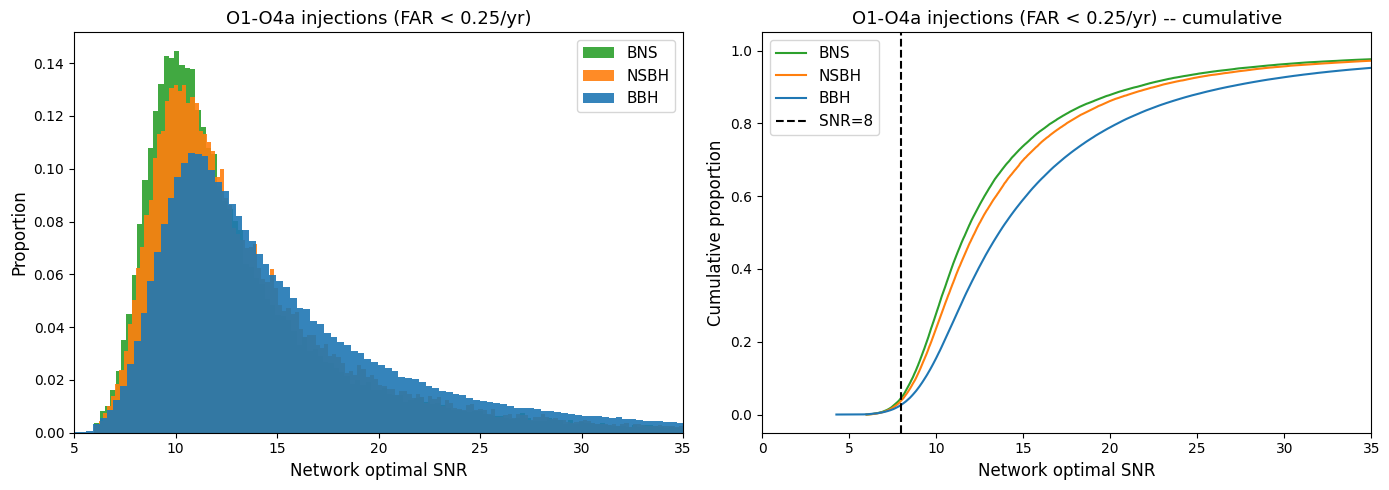

Plot saved to SNR_injections_cumulative.png


In [231]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"BBH": "C0", "NSBH": "C1", "BNS": "C2"}

for cat in ["BNS", "NSBH", "BBH"]:
    mask = labels == cat
    snr_cat = np.sort(snr_sel[mask])

    # Left panel: normalized histogram
    # density=True normalizes so that the integral = 1
    # This allows comparison between categories despite very different counts
    axes[0].hist(
        snr_cat, bins=3000, density=True, alpha=0.9, color=colors[cat], label=cat
    )

    # Right panel: empirical cumulative distribution function (ECDF)
    # x-axis: SNR values sorted in ascending order
    # y-axis: fraction of events with SNR <= x
    axes[1].plot(snr_cat, np.linspace(0, 1, len(snr_cat)), color=colors[cat], label=cat)

# Reference line at SNR = 8 (typical BBH detection threshold)
axes[1].axvline(8, color="black", linestyle="--", label="SNR=8")

# Formatting
axes[0].set_xlabel("Network optimal SNR", fontsize=12)
axes[0].set_ylabel("Proportion", fontsize=12)
axes[0].set_title(f"O1-O4a injections (FAR < {FAR_THRESHOLD}/yr)", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_xlim(5, 35)

axes[1].set_xlabel("Network optimal SNR", fontsize=12)
axes[1].set_ylabel("Cumulative proportion", fontsize=12)
axes[1].set_title(
    f"O1-O4a injections (FAR < {FAR_THRESHOLD}/yr) -- cumulative", fontsize=13
)
axes[1].set_xlim(0, 35)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("SNR_injections_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to SNR_injections_cumulative.png")

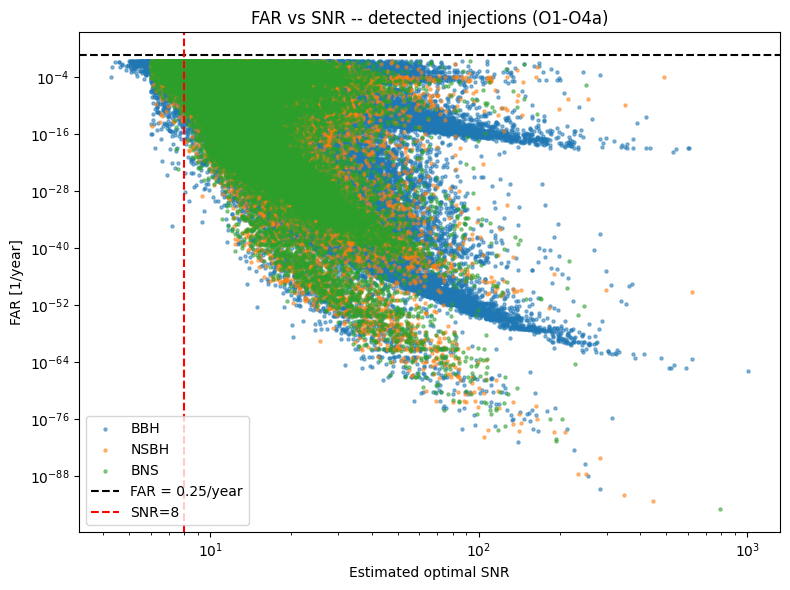

In [232]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {"BBH": "C0", "NSBH": "C1", "BNS": "C2"}

for cat in ["BBH", "NSBH", "BNS"]:
    mask = labels == cat

    ax.scatter(
        snr_sel[mask], far_sim[sel][mask], alpha=0.5, s=5, color=colors[cat], label=cat
    )

ax.axhline(4.0, color="black", linestyle="--", label="FAR = 0.25/year")
ax.set_xlabel("Estimated optimal SNR")
ax.set_ylabel("FAR [1/year]")
ax.set_yscale("log")
ax.set_xscale("log")
ax.axvline(8, color="red", linestyle="--", label="SNR=8")
ax.set_title("FAR vs SNR -- detected injections (O1-O4a)")
plt.savefig("SNR_FAR.png", dpi=150, bbox_inches="tight")
ax.legend()
plt.tight_layout()
plt.show()

## Notes and caveats

### On the SNR used here
We use `estimated_optimal_snr_net`, which is a **theoretical upper bound** on the actual
observed SNR. It is computed from reference PSDs and does not account for:
- Non-Gaussian noise fluctuations
- Pipeline-specific cuts (chi-squared tests, coherence tests, etc.)
- The actual matched-filter output

This is why some BNS injections appear at SNR < 8, whereas real BNS detections
are typically found at SNR ~ 10+. The real observed SNR from pipelines
(e.g., `o4a_gstlal_ranking_statistic`) is only available for O3+O4a injections.

### On the population weighting
This plot does **not** apply the Fullpop-4 population weights (`weights` column).
To reproduce Amanda's weighted plot, one would need to resample the injections
according to these weights, as done by `gwpopulation_pipe`.

### On the number of injections
The large number of injections (~1.7M total) is by design: population inference
requires N_eff >> N_detected to get precise estimates. With ~289 real detections,
we need at least ~10,000 effective injection samples.

## OBserved data from public GWTC-5.0 catalog release : from O1 to O4b

In [233]:
from astropy.table import Table

In [234]:
# ── Load ──────────────────────────────────────────────────────────────────────
table = Table.read("../data/GWTC-5.0_from_O1-to-O4b.csv", format="ascii.csv")
# Garder seulement les événements avec masses connues

print("Table length before filtering:", len(table))

table = table[~table["mass_1_source"].mask & ~table["mass_2_source"].mask]

print("Table length after filtering:", len(table))

Table length before filtering: 391
Table length after filtering: 282


In [235]:
# ── Classification from masses ────────────────────────────────────────────────
NS_MAX = 2.5
classification = []
for row in table:
    m1 = row["mass_1_source"]
    m2 = row["mass_2_source"]
    if m1 < NS_MAX and m2 < NS_MAX:
        classification.append("BNS")
    elif m1 >= NS_MAX and m2 < NS_MAX:
        classification.append("NSBH")
    else:
        classification.append("BBH")
table["classification"] = classification

Real       : 4.5 → 78.6
Injections : 4.3 → 1006.9


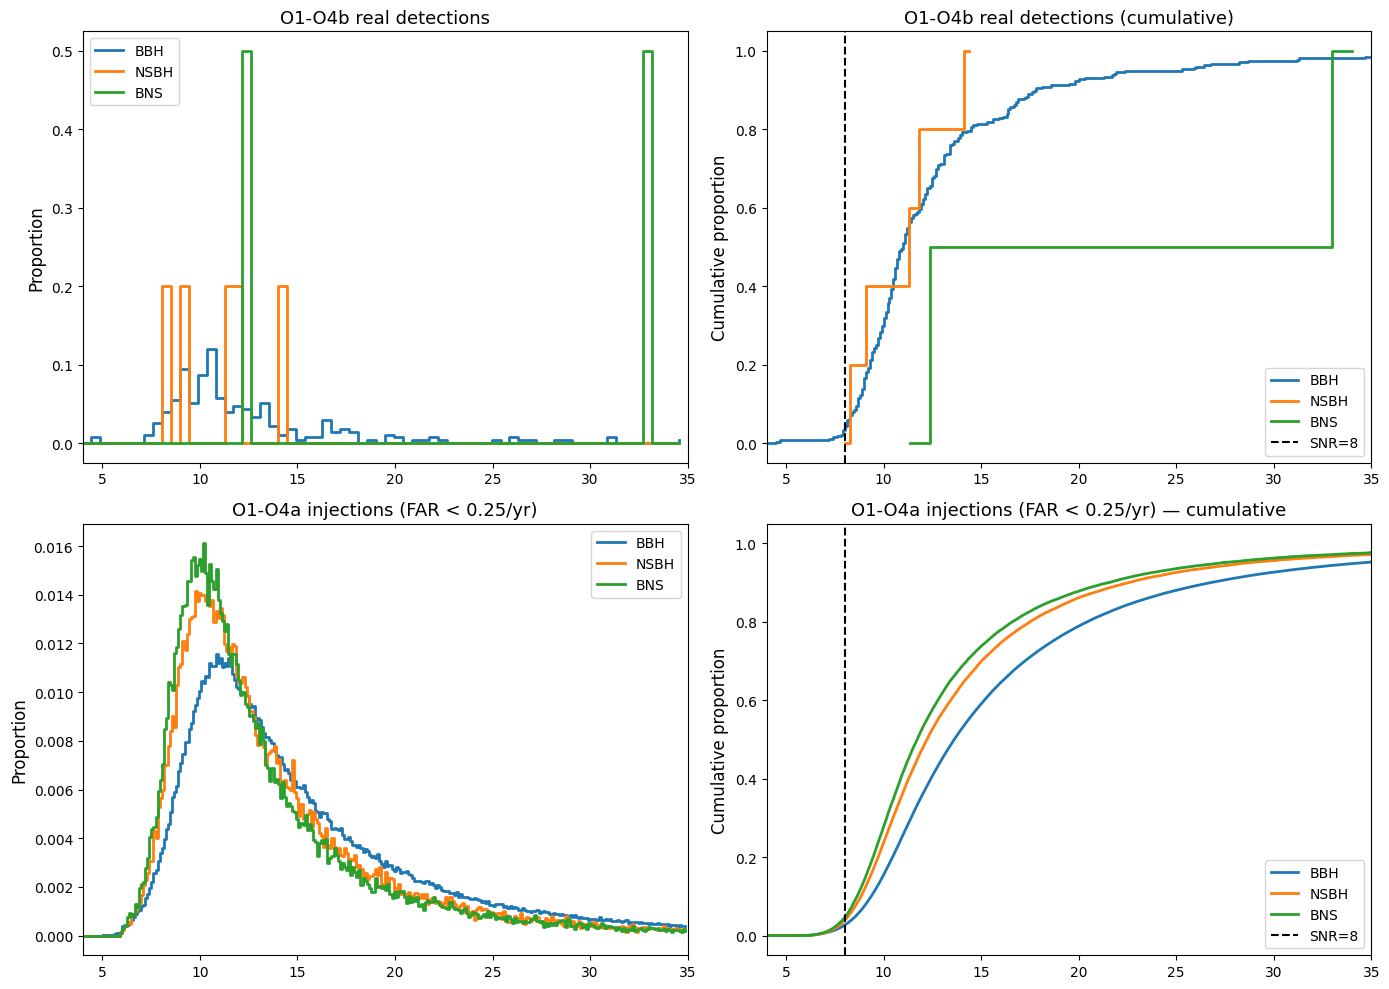

In [238]:
from scipy.stats import ecdf

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = {"BBH": "C0", "NSBH": "C1", "BNS": "C2"}
# Real detections: fewer events so fewer bins

# Real detections
snr_real_all = np.array(table["network_matched_filter_snr"])
snr_min_real = snr_real_all.min()
snr_max_real = snr_real_all.max()

# Injections
snr_min_inj = snr_sel.min()
snr_max_inj = snr_sel.max()

print(f"Real       : {snr_min_real:.1f} → {snr_max_real:.1f}")
print(f"Injections : {snr_min_inj:.1f} → {snr_max_inj:.1f}")

# Bins with margin on both sides
snr_bins_real = np.linspace(snr_min_real - 1, 35, 70)
snr_bins_inj = np.linspace(snr_min_inj - 1, 35, 300)


for cat in ["BBH", "NSBH", "BNS"]:
    # ── Row 0: Real detections ─────────────────────────────────────────────
    mask_real = np.array(table["classification"]) == cat
    snr_real = np.array(table[mask_real]["network_matched_filter_snr"])

    counts, edges = np.histogram(snr_real, bins=snr_bins_real)
    axes[0, 0].step(
        edges[:-1],
        counts / len(snr_real),
        where="post",
        color=colors[cat],
        linewidth=2,
        label=cat,
    )

    res = ecdf(snr_real)
    res.cdf.plot(ax=axes[0, 1], color=colors[cat], linewidth=2, label=cat)

    # ── Row 1: Injections ──────────────────────────────────────────────────
    mask_inj = labels == cat
    snr_inj = snr_sel[mask_inj]

    counts_inj, edges_inj = np.histogram(snr_inj, bins=snr_bins_inj)
    axes[1, 0].step(
        edges_inj[:-1],
        counts_inj / len(snr_inj),
        where="post",
        color=colors[cat],
        linewidth=2,
        label=cat,
    )

    res_inj = ecdf(snr_inj)
    res_inj.cdf.plot(ax=axes[1, 1], color=colors[cat], linewidth=2, label=cat)

# Reference lines
for ax in [axes[0, 1], axes[1, 1]]:
    ax.axvline(8, color="black", linestyle="--", linewidth=1.5, label="SNR=8")

# Titles
axes[0, 0].set_title("O1-O4b real detections", fontsize=13)
axes[0, 1].set_title("O1-O4b real detections (cumulative)", fontsize=13)
axes[1, 0].set_title(f"O1-O4a injections (FAR < {FAR_THRESHOLD}/yr)", fontsize=13)
axes[1, 1].set_title(
    f"O1-O4a injections (FAR < {FAR_THRESHOLD}/yr) — cumulative", fontsize=13
)


# Formatting
for ax in axes.flatten():
    ax.legend(fontsize=10)

axes[0, 0].set_ylabel("Proportion", fontsize=12)
axes[0, 1].set_ylabel("Cumulative proportion", fontsize=12)
axes[1, 0].set_ylabel("Proportion", fontsize=12)
axes[1, 1].set_ylabel("Cumulative proportion", fontsize=12)


# xlim adapted to each row
axes[0, 0].set_xlim(4, 35)
axes[0, 1].set_xlim(4, 35)
axes[1, 0].set_xlim(4, 35)
axes[1, 1].set_xlim(4, 35)

plt.tight_layout()
plt.savefig("SNR_real_vs_injections.png", dpi=150)
plt.show()

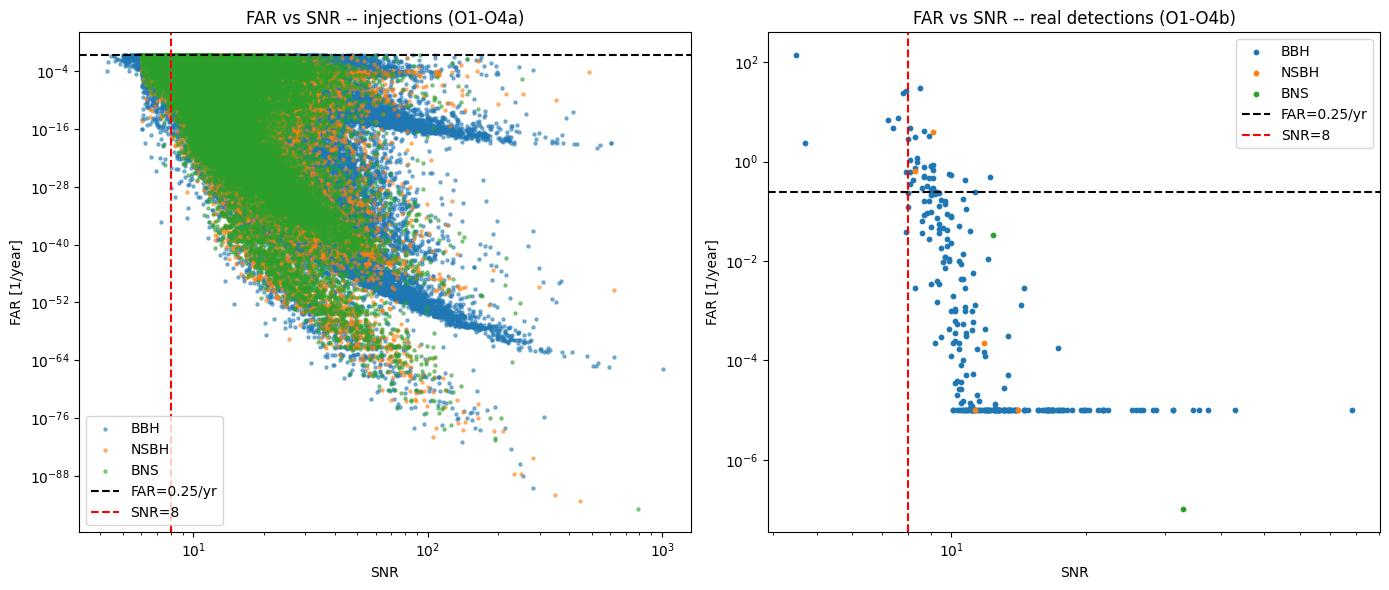

In [237]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Injections
for cat in ["BBH", "NSBH", "BNS"]:
    mask = labels == cat
    axes[0].scatter(
        snr_sel[mask], far_sim[sel][mask], alpha=0.5, s=5, color=colors[cat], label=cat
    )

axes[0].set_title("FAR vs SNR -- injections (O1-O4a)")

# Real detections
for cat in ["BBH", "NSBH", "BNS"]:
    mask_real = np.array(table["classification"]) == cat
    snr_real = np.array(table[mask_real]["network_matched_filter_snr"])
    far_real = np.array(table[mask_real]["far"])
    axes[1].scatter(snr_real, far_real, alpha=1, s=10, color=colors[cat], label=cat)

axes[1].set_title("FAR vs SNR -- real detections (O1-O4b)")

for ax in axes:
    ax.axhline(0.25, color="black", linestyle="--", label="FAR=0.25/yr")
    ax.axvline(8, color="red", linestyle="--", label="SNR=8")
    ax.set_xlabel("SNR")
    ax.set_ylabel("FAR [1/year]")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.legend()

plt.tight_layout()
plt.savefig("SNR_vs_FAR_injections-vs-real.png", dpi=150)
plt.show()